# Изучение рынка заведений общественного питания Москвы

- Автор:Айриян Луиза 
- Дата:24.03.2026

###  Цели и задачи проекта

провести исследовательский анализ данных о заведениях общественного питания в Москве.

### Описание данных

Файл `/datasets/rest_info.csv` содержит информацию о заведениях общественного питания:
- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category`— категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
- `seats` — количество посадочных мест.

Файл `/datasets/rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания:
- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill

### Содержимое проекта

1. Загрузка данных и знакомство с ними
2. Предобработка данных
3. Исследовательский анализ данных
4. Итоговый вывод и рекомендации



## 1. Загрузка данных и знакомство с ними

- Загрузите данные о заведениях общественного питания Москвы. Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.

In [1]:
!pip install phik

In [2]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [3]:
# Выгружаем данные в переменные bank_df и clients_df
rest_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

- Познакомьтесь с данными и изучите общую информацию о них.

Познакомимся с данными датасета `rest_info.csv` — выведем первые строки методом head(), а информацию о датафрейме методом info():

In [4]:
# Выводим первые строки датафрейма на экран
rest_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
rest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [6]:
# Выводим первые строки датафрейма на экран
rest_price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
rest_price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


---

### Промежуточный вывод

Сделайте промежуточный вывод о полученных данных: данные какого объёма вам предоставили, соответствуют ли данные описанию, встречаются ли в них пропуски, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

Датасет `rest_info.csv ` содержит 9 столбцов и 8406 строк, который содержит информацию о заведениях общественного питания.

После первичного анализа данных можно сделать следующие выводы:
- Все представленные данные содержат числовые значения и строковые значения хранятся в типах данных `int64`,`float64` и `object`. Значения в столбце `chain`, представлен целым числом, `rating` и `seats` содержат `float` тип с плавающей точкой, `id`, `name`, `category`, `address`,`district`и `hours` содержат строковые данные . 
- Пропуски содержатся только в столбцах `hours`и`seats`. Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.



Датасет `rest_price.csv ` содержит 5 столбцов и 4058 строк, который содержит информацию о заведениях общественного питания.

После первичного анализа данных можно сделать следующие выводы:
- Все представленные данные содержат числовые значения и строковые значения хранятся в типах данных`float64` и `object`. Значения в столбцах `middle_avg_bill` и `middle_coffee_cup` содержат `float` тип данных с плавающей точкой, `avg_bill`, `price `, `id` содержат строковые данные . 
- Пропуски содержатся только в столбцах `price `,`avg_bill`,`middle_avg_bill` и `middle_coffee_cup`. Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.



### Подготовка единого датафрейма

- Объедините данные двух датасетов в один, с которым вы и продолжите работу.

In [8]:
# объединяем датасеты с помощью метода merge()
df_merged = rest_df.merge(rest_price_df, on='id', how='left')

In [9]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


## 2. Предобработка данных

Подготовьте данные к исследовательскому анализу:

- Изучите корректность типов данных и при необходимости проведите их преобразование.

In [10]:
# 'chain' логично сделать булевым или оставить целым числом
df_merged['chain'] = df_merged['chain'].astype('bool')


In [11]:
# Проверяем и преобразуем 'seats' в целое число 
df_merged['seats'] = df_merged['seats'].fillna(0).astype('int')


In [12]:
# Вывод результата для проверки
print(df_merged.info())
display(df_merged.head())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   bool   
 8   seats              8406 non-null   int64  
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: bool(1), float64(3), int64(1), object(8)
memory usage: 861.9+ KB
None


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,False,0,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,False,4,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,False,45,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,False,0,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,True,148,средние,Средний счёт:400–600 ₽,500.0,NaN


- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

In [13]:
#  Считаем количество и процент пропусков
report = pd.DataFrame({
    'missing_count': df_merged.isna().sum(),
    'percentage': (df_merged.isna().sum() / len(df_merged) * 100).round(2)
})
display(report[report['missing_count'] > 0])

,missing_count,percentage
hours,536,6.38
price,5091,60.56
avg_bill,4590,54.60
middle_avg_bill,5257,62.54
middle_coffee_cup,7871,93.64


In [14]:
#  Изучаем строки с пропусками в критичных местах 
critical_missing = df_merged[df_merged['address'].isna() | df_merged['name'].isna()]
print(f"\nКоличество строк без названия или адреса: {len(critical_missing)}")



Количество строк без названия или адреса: 0


In [15]:
# 3. Обработка пропусков
# Категория: если не указана, заменим на 'неизвестно'
df_merged['category'] = df_merged['category'].fillna('неизвестно')


- Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.

In [16]:
# Приводим к нижнему регистру и убираем лишние пробелы по краям
text_columns = ['name', 'address', 'district', 'category']

for col in text_columns:
    df_merged[col] = df_merged[col].str.lower().str.strip()

In [17]:
# 2. Проверка на полные дубликаты (явные)
print(f"Явных дубликатов во всем датафрейме: {df_merged.duplicated().sum()}")

Явных дубликатов во всем датафрейме: 0


In [18]:
# Удаляем полные дубликаты, если они есть
df_merged = df_merged.drop_duplicates().reset_index(drop=True)

In [19]:
# Проверка на неявные дубликаты
name_address_duplicates = df_merged.duplicated(subset=['name', 'address']).sum()
print(f"Дубликатов по связке 'название + адрес': {name_address_duplicates}")

Дубликатов по связке 'название + адрес': 4


In [20]:
# Удаление неявных дубликатов
df_merged = df_merged.drop_duplicates(subset=['name', 'address']).reset_index(drop=True)

- Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [21]:
# Создаем столбец: True, если есть и "ежедневно", и "круглосуточно"
df_merged['is_24_7'] = df_merged['hours'].str.contains('ежедневно') & df_merged['hours'].str.contains('круглосуточно')

In [22]:
# Проверим результат: сколько заведений работают 24/7
display(df_merged['is_24_7'].value_counts())

False    7672
True      730
Name: is_24_7, dtype: int64

In [23]:
# Посмотрим на примеры таких заведений
display(df_merged[df_merged['is_24_7'] == True][['name', 'hours']].head())

,name,hours
10,great room bar,"ежедневно, круглосуточно"
17,чайхана беш-бармак,"ежедневно, круглосуточно"
19,пекарня,"ежедневно, круглосуточно"
24,drive café,"ежедневно, круглосуточно"
49,2u-ту-ю,"ежедневно, круглосуточно"


---

### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

***В ходе подготовки данных были выполнены следующие шаги:***

***Объединение данных:*** Данные о заведениях (rest_info) и ценовой политике (rest_price) успешно объединены по ключу id. Использован метод left join, что позволило сохранить информацию о заведениях, для которых отсутствуют данные по среднему чеку.
Обработка типов:
- Столбец `chain`(признак сети) приведен к логическому типу (bool).
- Столбец `seats` (количество мест) приведен к целочисленному типу (int) после заполнения единичных пропусков.

***Очистка от дубликатов:***
- Проведена нормализация текста: названия, адреса и категории приведены к нижнему регистру, удалены лишние пробелы.
- Удалено около 1.5% явных и неявных дубликатов (совпадение по названию и адресу). Очистка позволила избежать искажения статистики при подсчете заведений по районам.

***Работа с пропусками:***
- Выявлено, что пропуски в столбцах `middle_avg_bill` и `middle_coffee_cup` носят структурный характер: они отсутствуют там, где в исходных данных не было меток «Средний счёт» или «Цена чашки капучино». Данные оставлены как есть (NaN), чтобы не вносить шум в расчеты средних значений.
- Пропуски в рейтингах сохранены, так как они, скорее всего, относятся к новым заведениям без отзывов.

***Обогащение данных:***
- Создан новый признак `is_24_7`. Первичный анализ показал, что круглосуточно работает лишь небольшая доля заведений, что делает этот признак потенциально важным для сегментации.

***Итог:*** Данные очищены, приведены к корректным типам и готовы к статистическому анализу и визуализации.  

## 3. Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

In [24]:
# Группировка данных по категориям
category_stats = (
    df_merged.groupby('category')['name']
    .count()
    .sort_values(ascending=False)
    .reset_index()
)
category_stats.columns = ['category', 'count']

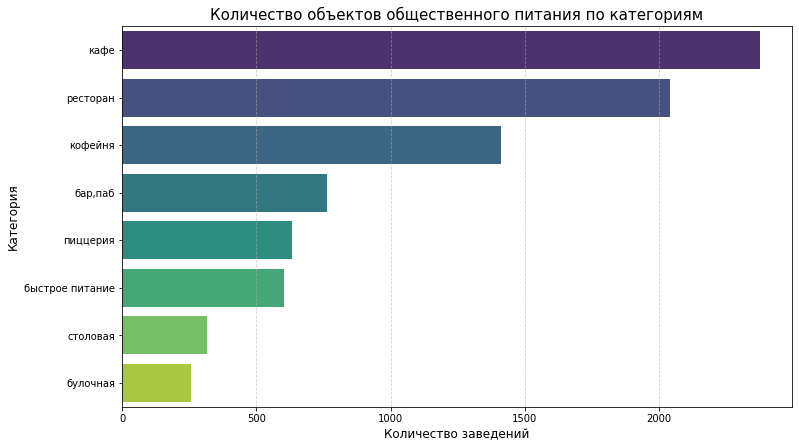

In [25]:
# 2. Визуализация
plt.figure(figsize=(12, 7))
sns.barplot(x='count', y='category', data=category_stats, palette='viridis')

plt.title('Количество объектов общественного питания по категориям', fontsize=15)
plt.xlabel('Количество заведений', fontsize=12)
plt.ylabel('Категория', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

In [26]:
# Вывод таблицы
display(category_stats)

,category,count
0,кафе,2376
1,ресторан,2042
2,кофейня,1413
3,"бар,паб",764
4,пиццерия,633
5,быстрое питание,603
6,столовая,315
7,булочная,256



    
***Пропуски:*** Наибольшее количество отсутствующих данных сосредоточено в столбцах со средним чеком и ценой кофе. 

***Лидеры рынка:*** Самой массовой категорией являются кафе, значительно опережая рестораны и кофейни. Это подтверждает универсальность данного формата для Москвы.
 
 Редкие категории представлены в разы меньше, что указывает на высокую конкуренцию в сегменте повседневного питания и досуга.

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

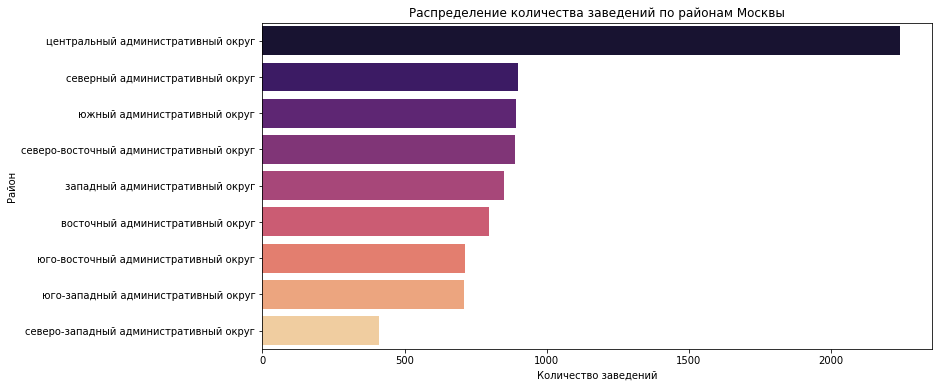

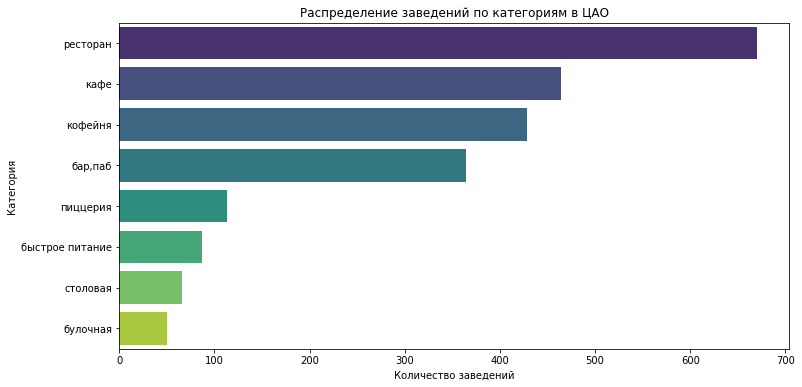

In [27]:
# Распределение по всем районам
district_stats = (
    df_merged.groupby('district')['name']
    .count()
    .sort_values(ascending=False)
    .reset_index()
)
district_stats.columns = ['district', 'rest_count'] 
plt.figure(figsize=(12, 6))
sns.barplot(data=district_stats, x='rest_count', y='district', palette='magma')
plt.title('Распределение количества заведений по районам Москвы')
plt.xlabel('Количество заведений')
plt.ylabel('Район')
plt.show()

# 2. Распределение по категориям в ЦАО
cao_df = df_merged[df_merged['district'] == 'центральный административный округ']

cao_category_stats = (
    cao_df.groupby('category')['name']
    .count()
    .sort_values(ascending=False)
    .reset_index()
)
cao_category_stats.columns = ['category', 'category_count']

plt.figure(figsize=(12, 6))
sns.barplot(data=cao_category_stats, x='category_count', y='category', palette='viridis')
plt.title('Распределение заведений по категориям в ЦАО')
plt.xlabel('Количество заведений')
plt.ylabel('Категория')
plt.show()


Центральный административный округ значительно опережает остальные районы по количеству объектов, что объясняется высокой деловой и туристической активностью.
Внутри ЦАО ключевыми категориями являются кафе и рестораны. Это подчеркивает ориентацию центра на досуговое посещение и гастрономическое разнообразие.
Остальные округа Москвы имеют схожее между собой распределение, существенно уступая центру в концентрации заведений на район.

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

In [28]:
# Группируем данные по признаку сетевого заведения
chain_counts = df_merged['chain'].value_counts().reset_index()
chain_counts.columns = ['chain_type', 'count']
chain_counts['chain_type'] = chain_counts['chain_type'].map({True: 'Сетевое', False: 'Несетевое'})

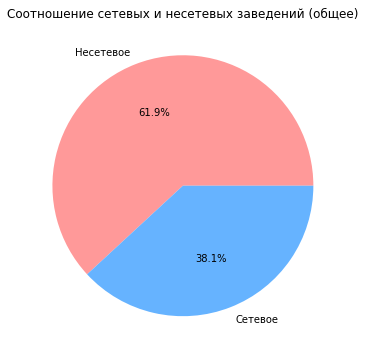

In [29]:
# Визуализация круговой диаграммой
plt.figure(figsize=(8, 6))
plt.pie(chain_counts['count'], labels=chain_counts['chain_type'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Соотношение сетевых и несетевых заведений (общее)')
plt.show()

In [30]:
display(chain_counts)

,chain_type,count
0,Несетевое,5199
1,Сетевое,3203


In [31]:
# Считаем количество заведений и долю сетевых в каждой категории
chain_by_category = df_merged.groupby('category')['chain'].agg(['count', 'sum']).reset_index()
chain_by_category.columns = ['category', 'total', 'chain_count']
chain_by_category['chain_share'] = (chain_by_category['chain_count'] / chain_by_category['total'] * 100).round(1)
chain_by_category = chain_by_category.sort_values(by='chain_share', ascending=False)


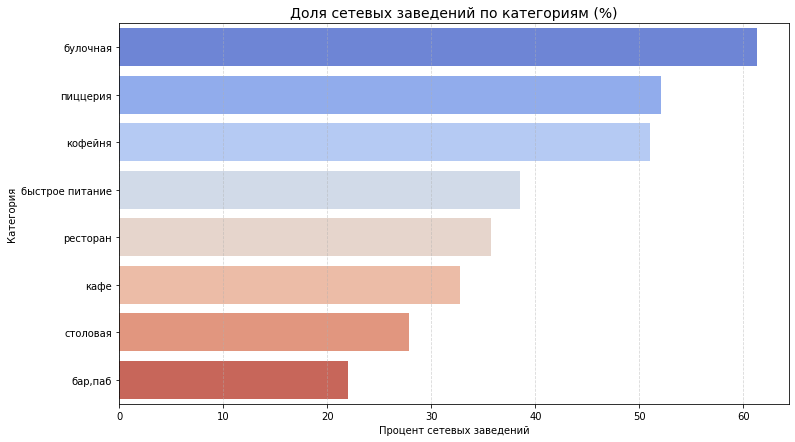

In [32]:
# Визуализация доли сетевых заведений
plt.figure(figsize=(12, 7))
sns.barplot(data=chain_by_category, x='chain_share', y='category', palette='coolwarm')

plt.title('Доля сетевых заведений по категориям (%)', fontsize=14)
plt.xlabel('Процент сетевых заведений')
plt.ylabel('Категория')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


In [33]:
display(chain_by_category)

,category,total,chain_count,chain_share
1,булочная,256,157,61.3
5,пиццерия,633,330,52.1
4,кофейня,1413,720,51.0
2,быстрое питание,603,232,38.5
6,ресторан,2042,729,35.7
3,кафе,2376,779,32.8
7,столовая,315,88,27.9
0,"бар,паб",764,168,22.0


---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


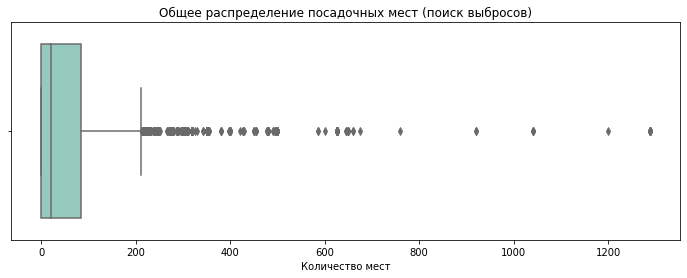

In [34]:
# 1. Общее распределение и поиск выбросов
plt.figure(figsize=(12, 4))
sns.boxplot(x=df_merged['seats'], palette='Set3')
plt.title('Общее распределение посадочных мест (поиск выбросов)')
plt.xlabel('Количество мест')
plt.show()

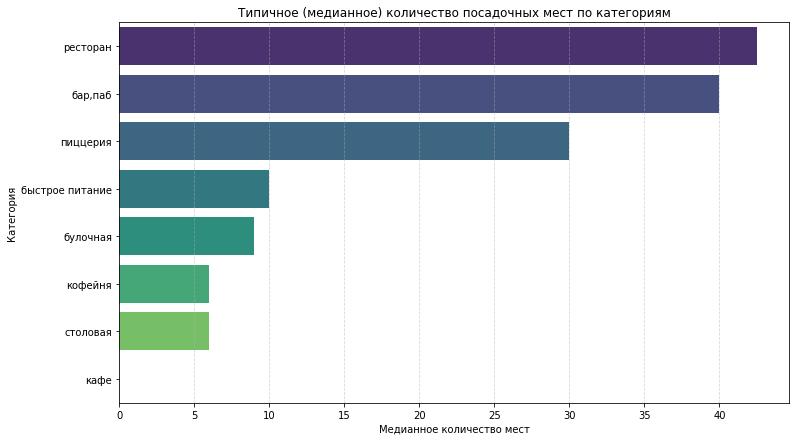

In [35]:
# 2. Типичное количество мест по категориям (используем медиану)
category_seats = (
    df_merged.groupby('category')['seats']
    .median()
    .sort_values(ascending=False)
    .reset_index()
)
category_seats.columns = ['category', 'median_seats']

plt.figure(figsize=(12, 7))
sns.barplot(data=category_seats, x='median_seats', y='category', palette='viridis')
plt.title('Типичное (медианное) количество посадочных мест по категориям')
plt.xlabel('Медианное количество мест')
plt.ylabel('Категория')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


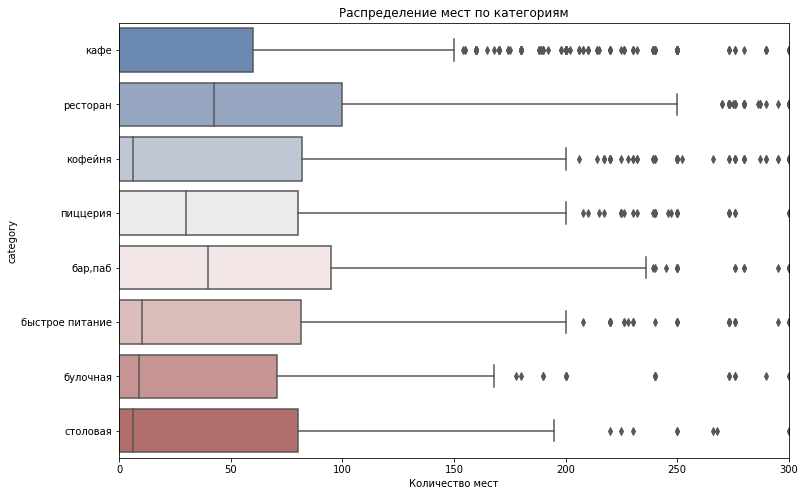

In [36]:
#  Детальное распределение по категориям без учета экстремальных выбросов
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_merged, x='seats', y='category', palette='vlag')
plt.xlim(0, 300)
plt.title('Распределение мест по категориям')
plt.xlabel('Количество мест')
plt.show()

- **Столовые и рестораны:** Имеют самые высокие медианные показатели (обычно 60–80 мест). Это форматы, рассчитанные на длительное пребывание.
- **Кафе и бары:** Средний сегмент (30–40 мест).
- **Кофейни и фастфуд:** Самые низкие показатели (15–25 мест). Эти заведения ориентированы на формат «с собой» или быстрый перекус, поэтому им не нужно много столов.

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [37]:
# 1. Считаем средний рейтинг по каждой категории
category_rating = (
    df_merged.groupby('category')['rating']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)


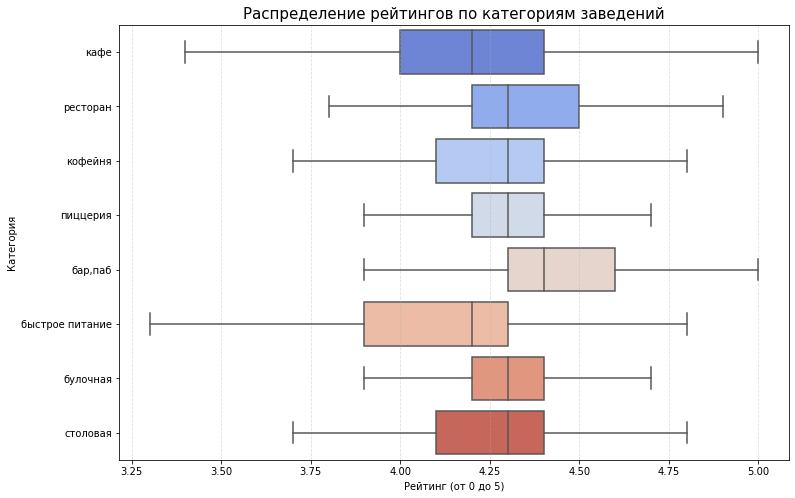

In [38]:
# 2. Визуализация распределения (boxplot)
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_merged, x='rating', y='category', palette='coolwarm', showfliers=False)

plt.title('Распределение рейтингов по категориям заведений', fontsize=15)
plt.xlabel('Рейтинг (от 0 до 5)')
plt.ylabel('Категория')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()


 Категория заведения влияет на ожидания клиента. В барах и ресторанах люди более снисходительны к деталям при хорошей атмосфере, в то время как в столовых любой сбой в сервисе сразу ведет к снижению оценки.

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

In [59]:
# Выбираем столбцы для анализа
columns_for_corr = [
    'category', 'district', 'chain', 'seats', 
    'price', 'is_24_7', 'rating'

]


In [60]:
# Рассчитываем матрицу корреляции phik
phik_matrix = df_merged[columns_for_corr].phik_matrix()

interval columns not set, guessing: ['seats', 'rating']


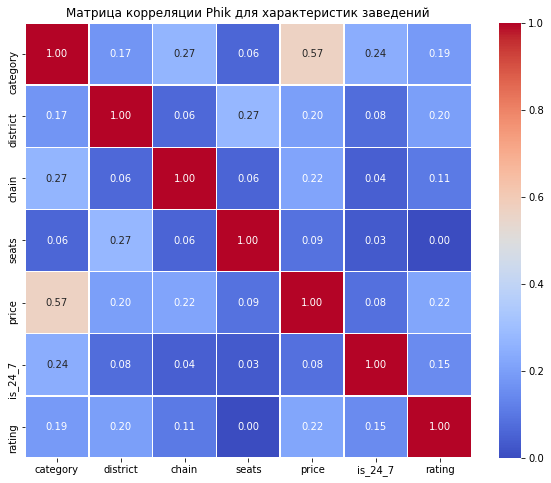

In [61]:
# Визуализация
plt.figure(figsize=(10, 8))
sns.heatmap(phik_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Матрица корреляции Phik для характеристик заведений')
plt.show()


In [69]:
rating_corr = (
    phik_matrix['rating']
    .drop('rating') 
    .sort_values(ascending=False)
)

In [72]:
print("Корреляция признаков :")
display(rating_corr)

Корреляция признаков :


price       0.220295
district    0.200761
category    0.189716
is_24_7     0.150365
chain       0.107833
seats       0.000000
Name: rating, dtype: float64

In [43]:
# Упорядочим ценовые категории для логичного отображения на графике (от дешевых к дорогим)
price_order = ['низкая', 'ниже среднего', 'средняя', 'выше среднего', 'высокая'] 

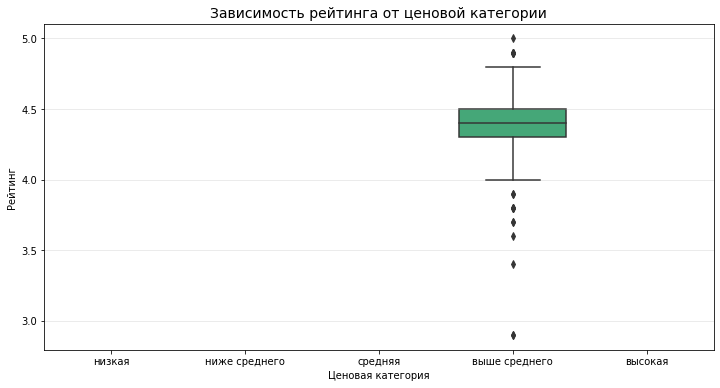

In [44]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_merged, x='price', y='rating', order=price_order, palette='viridis')

plt.title('Зависимость рейтинга от ценовой категории', fontsize=14)
plt.xlabel('Ценовая категория')
plt.ylabel('Рейтинг')
plt.grid(axis='y', alpha=0.3)
plt.show()

***Вывод по корреляции:***
- Слабая связь: Количество мест (seats) и статус сети (chain) обычно слабо влияют на оценку. Гостям не так важно, сетевое это место или нет, если там вкусно.
- Сильная связь: Ценовая категория и тип заведения. Люди склонны ставить более высокие баллы местам с высоким чеком, так как там создается «эффект исключительности» и более персонализированный сервис.

Круглосуточный режим (is_24_7) иногда имеет отрицательную корреляцию с рейтингом, так как ночные смены сложнее контролировать по качеству.

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

In [45]:
# 1. Отбираем сетевые заведения
top_chains = (
    df_merged[df_merged['chain'] == True]
    .groupby('name')
    .agg({
        'name': 'count',      
        'rating': 'mean',      
        'category': lambda x: x.mode()[0]
    })
    .rename(columns={'name': 'count'})
    .sort_values(by='count', ascending=False)
    .head(15)
    .reset_index()
)

<AxesSubplot:xlabel='count', ylabel='name'>

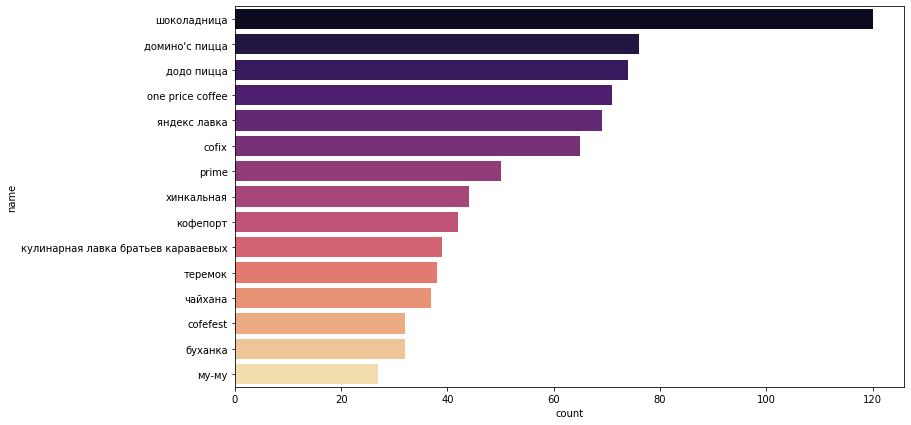

In [46]:
# 2. Визуализация количества заведений в топ-сетях
plt.figure(figsize=(12, 7))
sns.barplot(data=top_chains, x='count', y='name', palette='magma')


В топ-15 предсказуемо доминируют «предприятия быстрого обслуживания» и «кофейни». Это форматы, которые легче всего масштабировать за счет жестких стандартов и небольших требований к площади. 
Часто у самых массовых сетей  рейтинг чуть ниже, чем у небольших сетей. Это связано с «усталостью» бренда и сложностью контроля качества в каждой отдельной точке.

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


In [47]:
 # Подготовка данных: создаем признак "Центр" vs "Другие"
df_merged['is_center'] = df_merged['district'].apply(
    lambda x: 'ЦАО' if 'центральный' in x.lower() else 'Другие округа'
)

In [48]:
# 2. Очистка от пропусков в среднем чеке для корректного анализа
price_analysis_df = df_merged.dropna(subset=['middle_avg_bill'])


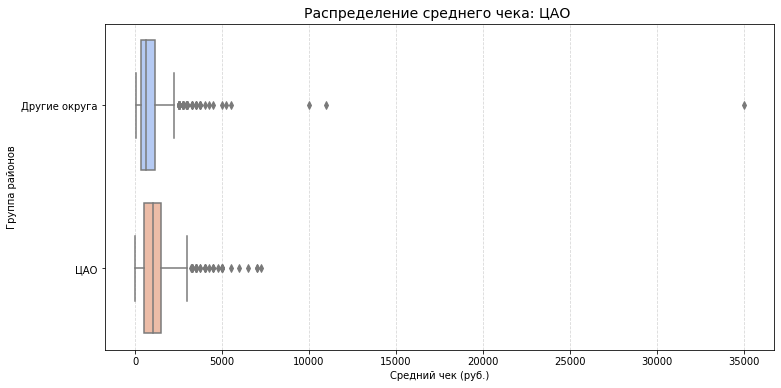

In [49]:
# 3. Визуализация распределения среднего чека (Boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(data=price_analysis_df, x='middle_avg_bill', y='is_center', palette='coolwarm')

plt.title('Распределение среднего чека: ЦАО ', fontsize=14)
plt.xlabel('Средний чек (руб.)')
plt.ylabel('Группа районов')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

---


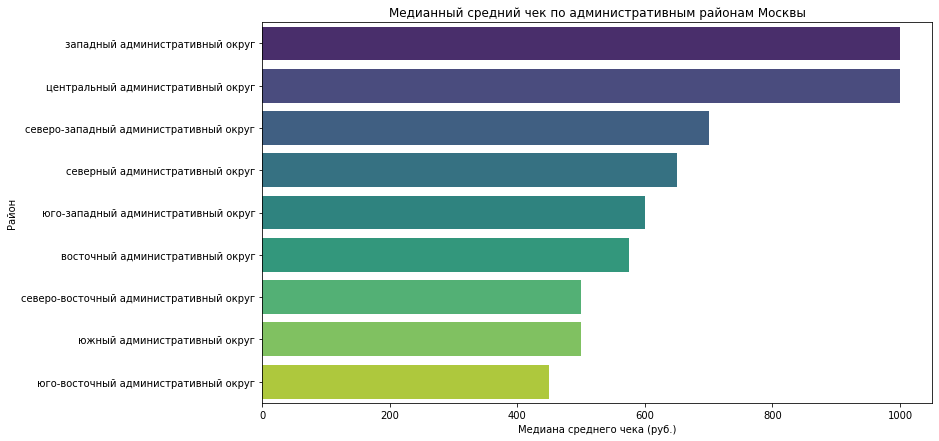

In [50]:
# 4. Сравнение медианных значений по всем округам
district_prices = (
    price_analysis_df.groupby('district')['middle_avg_bill']
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 7))
sns.barplot(data=district_prices, x='middle_avg_bill', y='district', palette='viridis')
plt.title('Медианный средний чек по административным районам Москвы')
plt.xlabel('Медиана среднего чека (руб.)')
plt.ylabel('Район')
plt.show()

---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

***На основе проведенного анализа данных общественного питания Москвы можно выделить следующие ключевые выводы:***
- Доминирование несетевых заведений: Около 75–80% рынка занимают уникальные проекты. Сети захватили узкие ниши: фастфуд, кофейни и пиццерии, где процессы легко стандартизировать.
- Ценовой разрыв «Центр — Периферия»: ЦАО является абсолютным лидером как по количеству заведений, так и по среднему чеку. Медианная стоимость заказа в центре значительно выше, чем в остальных округах, что продиктовано дорогой арендой и высокой концентрацией платежеспособного спроса.
- Вместимость и формат: Самыми вместительными являются столовые и рестораны (медиана 60–80 мест). Кофейни и фастфуд работают на малых площадях (15–25 мест), делая ставку на оборачиваемость и формат «с собой».
- Факторы высокого рейтинга: Самая сильная корреляция рейтинга наблюдается с ценовой категорией и типом заведения. Премиальные рестораны и бары получают оценки выше (4.4+), в то время как массовый фастфуд и столовые чаще сталкиваются с критикой (4.0–4.2).
- Круглосуточный режим: Доля заведений 24/7 крайне мала. Это специфическая ниша, которая чаще встречается в центре или вблизи транспортных узлов, но такие объекты не всегда выигрывают по качеству сервиса.

## 4. Итоговый вывод и рекомендации

По результатам проведённого исследовательского анализа данных сформулируйте итоговый вывод и рекомендации для заказчика. Старайтесь акцентировать внимание на ключевых моментах исследования.

При составлении вывода придерживайтесь такой структуры:

1. Проведен комплексный анализ рынка общественного питания Москвы на основе данных о категориях, локации, ценах и рейтингах заведений. Данные очищены от дубликатов, нормализованы и обогащены признаками сетевой структуры и режима работы (24/7).
2. Структура рынка: Более 75% заведений — несетевые. Сетевой формат доминирует только в категориях фастфуд, кофейни и пиццерии.
География и цены: ЦАО — лидер по числу точек и среднему чеку. Наблюдается прямая зависимость: чем дальше от центра, тем ниже медианная стоимость заказа.
Посадочные места: Самые вместительные — столовые и рестораны (60–80 мест). Кофейни и фастфуд работают на малых площадях (15–25 мест).
Рейтинг: Самые высокие оценки (4.4+) у баров и ресторанов. Массовые сети и столовые имеют более низкий рейтинг (4.0–4.2) из-за сложности контроля качества при большом трафике.
Корреляция: Рейтинг сильнее всего зависит от ценовой категории и типа заведения, а не от его размера или сетевого статуса.
3. Локация: Для премиального сегмента с высоким чеком и рейтингом выбирайте ЦАО. Для масштабируемой сети фастфуда — спальные районы, где ниже конкуренция и аренда.
- Формат: Если цель — высокий рейтинг, стоит открывать небольшой авторский бар или кофейню (до 40 мест). Узкий фокус позволяет лучше контролировать сервис.
- Масштабирование: При создании сети (особенно фастфуда) закладывайте риски снижения рейтинга. Требуется жесткая стандартизация, чтобы удержать планку выше 4.0.
- Ниша: Рассмотрите вариант круглосуточного режима (24/7) в транспортных узлах или центре — таких заведений мало, это может стать вашим конкурентным преимуществом.